### sentiment analysis

In [1]:
import pandas as pd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

100%|██████████| 16.9M/16.9M [00:00<00:00, 66.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mksaad/arabic-sentiment-twitter-corpus/versions/2


In [3]:
import os
os.listdir(path)

['train_Arabic_tweets_positive_20190413.tsv',
 'train_Arabic_tweets_negative_20190413.tsv',
 'test_Arabic_tweets_negative_20190413.tsv',
 'test_Arabic_tweets_positive_20190413.tsv',
 'arabic_tweets']

In [4]:
train_Arabic_tweets_positive=pd.read_csv(path+'/train_Arabic_tweets_positive_20190413.tsv',sep='\t',header=None,
    names=['sentiment', 'text']
)
train_Arabic_tweets_negative=pd.read_csv(path+'/train_Arabic_tweets_negative_20190413.tsv',sep='\t',header=None,
    names=['sentiment', 'text']
)
test_Arabic_tweets_positive=pd.read_csv(path+ '/test_Arabic_tweets_positive_20190413.tsv',sep='\t',header=None,
    names=['sentiment', 'text']
)
test_Arabic_tweets_negative=pd.read_csv(path+'/test_Arabic_tweets_negative_20190413.tsv',sep='\t',header=None,
    names=['sentiment', 'text']
)


In [5]:
x_train = pd.concat(
    [train_Arabic_tweets_positive[['sentiment', 'text']],
     train_Arabic_tweets_negative[['sentiment', 'text']]],
    axis=0
).sample(frac=1, random_state=42)

In [6]:
x_train

,sentiment,text
21985,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊
7725,pos,تيشرت القائد 💙
9147,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...
14470,neg,المونافري طلع برهوش .. سدينا 😤
4329,neg,منو خر بيتهم مثلنا 😩
...,...,...
11284,pos,يلامسون قلبي أولئك الذين ينتبهون لتفاصيلي الصغ...
21971,neg,#الهلال_الاهلي #حسين_عبدالغني سبق وان تكررت له...
15397,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...
860,pos,بحياتك يا ولدى امرأة 👰 عيناها سبحان المعبود 👀 ...


In [7]:
x_test = pd.concat(
    [test_Arabic_tweets_positive[['sentiment', 'text']],
     test_Arabic_tweets_negative[['sentiment', 'text']]],
    axis=0
).sample(frac=1, random_state=42)

In [8]:
x_test

,sentiment,text
1078,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...
3563,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...
3299,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ..."
2142,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...
5285,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...
...,...,...
5532,neg,. . بعد أن ذبلت القلوب 😔
5191,pos,انا عني و دي ازود رابع 😀
5390,pos,*عشائيات* *صلاةالمغرب*سورة الحاقة[١٣-٣٧] 📽*مرئ...
860,pos,وإليك حن الجذع و هو كصخرة أفلا يحن القلب ، وهو...


### Handle Emotion

In [9]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.0 MB/s eta 0:00:00


In [13]:
import emoji
import re

emoji_emotion_map = {
    # sadness - حزن
    '😭': 'حزن',
    '😢': 'حزن',
    '😔': 'حزن',
    '😞': 'حزن',

    # anger - غضب
    '😡': 'غضب',
    '🤬': 'غضب',
    '😤': 'غضب',
    '😠': 'غضب',

    # joy - فرح
    '😂': 'فرح',
    '😄': 'فرح',
    '😊': 'فرح',
    '😁': 'فرح',

    # love - حب
    '❤️': 'حب',
    '😍': 'حب',
    '🥰': 'حب',
    '💕': 'حب',

    # fear - خوف
    '😱': 'خوف',
    '😨': 'خوف',
    '😰': 'خوف',

    # disgust - اشمئزاز
    '🤢': 'اشمئزاز',
    '🤮': 'اشمئزاز',

    # surprise - مفاجأة
    '😲': 'مفاجأة',
    '😮': 'مفاجأة',
}


In [10]:
def clean_text(text):
    # 1. Replace emojis with emotion words
    for em, emotion in emoji_emotion_map.items():
        text = text.replace(em, f' {emotion} ')

    # 2. Remove any remaining emojis not in map
    text = emoji.replace_emoji(text, replace='')

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove mentions & hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [14]:
x_train['text'] = x_train['text'].apply(clean_text)
x_test['text']  = x_test['text'].apply(clean_text)

# Verify
x_train['text'].head(10)

,text
21985,مقال يدور حول الحمى يوشك ان يقع فيه فرح
7725,تيشرت القائد
9147,وكل السعوديه بدو حتى الحاضره منهم من اصل بدوي ...
14470,المونافري طلع برهوش سدينا غضب
4329,منو خر بيتهم مثلنا
17566,نقاش حاد محدش يتدخل ياجماعة اللي هيتدخل هيتعور...
10910,كلين للتنحيف والرشاقة متاابعة دورية خلال مدة ا...
1890,من يضمك
1452,صباح الخير بتوقيت الفجيرة
17050,يا حظ حقون المسابقات ومشاهير تويتر دايم الناس ...


## Remove StopWords

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
arabic_stopwords = set(stopwords.words('arabic'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in arabic_stopwords]
    return ' '.join(filtered)
x_train["text"] =  x_train["text"] .apply (remove_stopwords)
x_test["text"] =  x_test["text"] .apply (remove_stopwords)

In [17]:
x_train.head(100)

,sentiment,text
21985,pos,مقال يدور حول الحمى يوشك ان يقع فرح
7725,pos,تيشرت القائد
9147,neg,وكل السعوديه بدو الحاضره منهم اصل بدوي انا قصد...
14470,neg,المونافري طلع برهوش سدينا غضب
4329,neg,منو خر بيتهم مثلنا
...,...,...
13743,neg,الله نطاج وجه مو مخبز فرح فرح ساعة_ راكعته كيل...
20170,pos,دعا رسول الله ﷺ لعائشة اللهم اغفر لعائشة تقدم ...
12772,neg,يجي دورنا عشان الاجازه
4203,neg,تخيلوا ان الزواجات عندنا مكلفه بشكل مقرف لازم ...


### Tokenization

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
tokenizer=Tokenizer(oov_token="<ovv>")
tokenizer.fit_on_texts(x_train['text'])

In [20]:
x_train['text']=tokenizer.texts_to_sequences(x_train['text'])
x_test['text']=tokenizer.texts_to_sequences(x_test['text'])

In [21]:
x_train['text']

,text
21985,"[3166, 533, 247, 31947, 31948, 10, 3723, 3]"
7725,"[16491, 3724]"
9147,"[211, 1398, 4254, 31949, 500, 4255, 21459, 9, ..."
14470,"[31951, 391, 31952, 31953, 39]"
4329,"[1217, 31954, 16493, 16494]"
...,...
11284,"[17788, 32, 12099, 17789, 3315, 9131, 106, 118..."
21971,"[1086, 180, 1234, 1300, 1301, 367, 1302, 1135,..."
15397,"[188, 95, 189, 59, 190, 172, 4, 38, 167, 186, ..."
860,"[4656, 11226, 1520, 11227, 11228, 9679, 8638, ..."


In [22]:
from operator import index
for word ,index in tokenizer.word_index.items():
  print(word,index)

Streaming output truncated to the last 5000 lines.
تجاوبي 63453
بالمود 63454
خصال 63455
لكانوا 63456
يهتمون 63457
يشكون 63458
مرضوا 63459
ياخالتي 63460
رسام 63461
المفك 63462
الهشتاقات 63463
المواويل 63464
توصله 63465
سلامى 63466
فهمتني 63467
والخمول 63468
سهرانه 63469
وحداني 63470
هالساعه 63471
الكارا 63472
الجاب 63473
اركان 63474
تهترئ 63475
ملكوش 63476
متتكلموش 63477
فيري 63478
بقبل 63479
جايني 63480
أحساس 63481
مايمرني 63482
ويحرك 63483
خلاياي 63484
جامدين 63485
very 63486
beautiful 63487
mashalah 63488
إحمي 63489
أعينهم 63490
وأخبار 63491
سعادتهم 63492
أمراض 63493
عافيتهم 63494
أعذهم 63495
دايونسيس 63496
ستراي 63497
المرتبه 63498
قاون 63499
للألبومات 63500
ياعزيزي 63501
والهلا 63502
المخفيه 63503
مشهوره 63504
معانيها 63505
كانهم 63506
التريلات 63507
للتعاقد 63508
ارون 63509
بيساكا 63510
وسيكون 63511
دالو 63512
دارميان 63513
ويونغ 63514
محفوظ 63515
فبقاء 63516
وأصحابي 63517
لاتفجعني 63518
ماجاب 63519
وشكاالكم 63520
وضح 63521
ادرب 63522
عشاك 63523
تعادلتوا 63524
صلاحيات 63525
اباده 

In [23]:
vocab_len=len(tokenizer.word_index)
vocab_len

68452

In [24]:
from collections import Counter
sequance_length=[len(seq) for seq in x_train['text']]
length_counts = Counter(sequance_length)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [25]:
length_counts.most_common(5)

[(3, 3778), (4, 3736), (5, 3177), (8, 3075), (12, 2925)]

In [26]:
from matplotlib import pyplot as plt

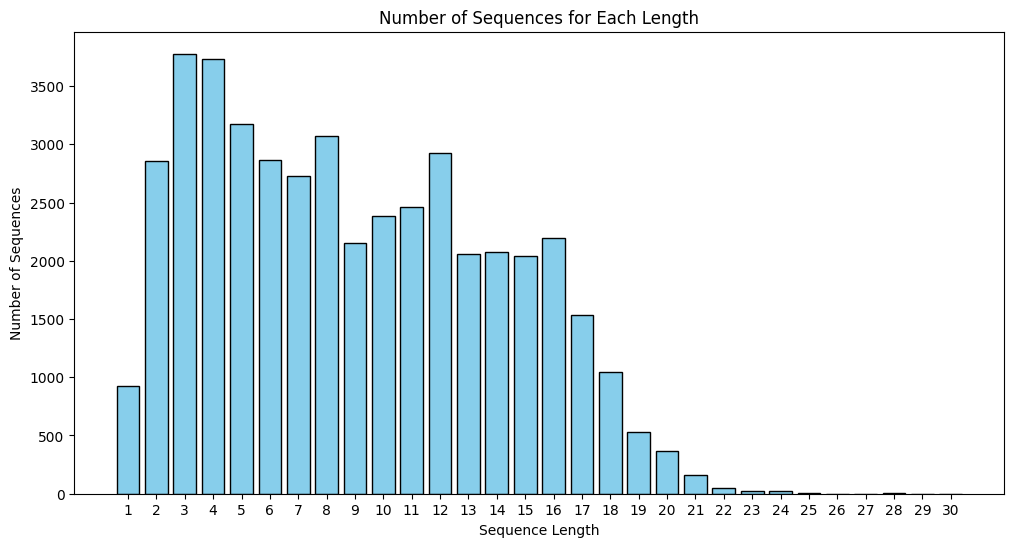

In [27]:
from collections import Counter

sequence_lengths = [len(seq) for seq in x_train['text']]
length_counts = Counter(sequence_lengths)

lengths = list(range(1, 31))
counts = [length_counts.get(length, 0) for length in lengths]

plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')

plt.title('Number of Sequences for Each Length')
plt.xlabel('Sequence Length')
plt.ylabel('Number of Sequences')

plt.xticks(range(1, 31))
plt.show()


## Padding

In [84]:
# Sequence Padding
from tensorflow import  keras
from keras.preprocessing.sequence import pad_sequences
X=pad_sequences(x_train['text'],
    maxlen=9,
    padding='post',
    truncating='post',
)

In [85]:
x=x_train['text']
y=x_train['sentiment']

In [86]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

## RNN

In [89]:
import seaborn as sns
import tensorflow as tf

In [90]:
input_shape=9

In [91]:
model = tf.keras.models.Sequential([
    # Embedding layer
tf.keras.layers.Embedding(vocab_len+1, 32, input_shape=[input_shape]),  # Embedding layer

    # RNN layer
tf.keras.layers.SimpleRNN(32, return_sequences=True),  # RNN layer

    # Batch Normalization after RNN
tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # RNN layer
tf.keras.layers.SimpleRNN(32, return_sequences=False),  # RNN layer

    # Batch Normalization after RNN
tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
 tf.keras.layers.Dropout(0.25),  # Dropout layer

    # Dense output layer with softmax activation for multi-class classification
tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [92]:
x.shape

(45275,)

array([1, 1, 0, ..., 0, 1, 1])

In [93]:
X

array([[ 3166,   533,   247, ...,  3723,     3,     0],
       [16491,  3724,     0, ...,     0,     0,     0],
       [  211,  1398,  4254, ..., 21459,     9,  2382],
       ...,
       [  188,    95,   189, ...,     4,    38,   167],
       [ 4656, 11226,  1520, ...,  8638, 11229,  9737],
       [ 3266,  5738,  2788, ...,   167,    63,     0]], dtype=int32)

In [98]:
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X, y, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9754 - loss: 0.0669 - val_accuracy: 0.7940 - val_loss: 0.7154
Epoch 2/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 34s 30ms/step - accuracy: 0.9739 - loss: 0.0684 - val_accuracy: 0.7953 - val_loss: 0.6636
Epoch 3/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.9747 - loss: 0.0682 - val_accuracy: 0.8019 - val_loss: 0.7037
Epoch 4/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.9784 - loss: 0.0573 - val_accuracy: 0.7964 - val_loss: 0.7612
Epoch 5/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.9806 - loss: 0.0518 - val_accuracy: 0.7956 - val_loss: 0.7104
Epoch 6/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9801 - loss: 0.0499 - val_accuracy: 0.7958 - val_loss: 0.7747
Epoch 7/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.9809 - loss: 0.0470 - val_accuracy: 0.7914 - val_loss: 0.7776
Epoch 8/15
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.9813 -

In [99]:
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 9, 32)          │     2,190,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 9, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 9, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,584,581 (25.12 MB)

 Trainable params: 2,194,817 (8.37 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 4,389,636 (16.75 MB)

None


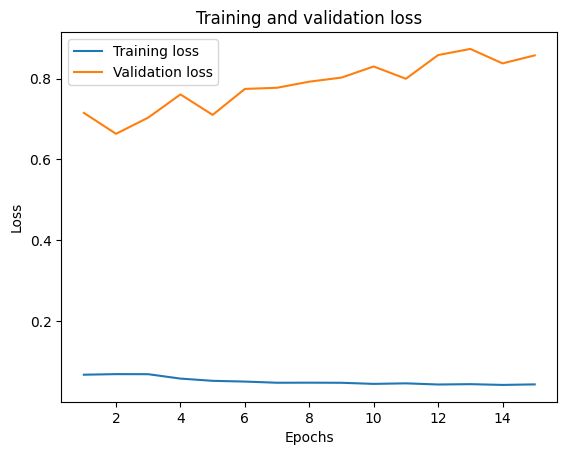

In [100]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

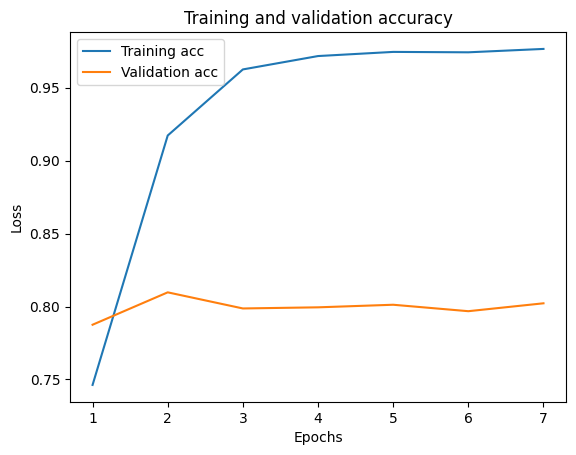

In [97]:
plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [101]:
model.save('my_model.keras')

In [124]:
# Prepare test data
x_test_seq = pad_sequences(x_test['text'], maxlen=9, padding='post', truncating='post')

# Encode test labels
from sklearn.preprocessing import LabelEncoder
le_test = LabelEncoder()
y_test_encoded = le_test.fit_transform(x_test['sentiment'])

print('Test samples:', x_test_seq.shape)
print('Label classes:', le_test.classes_)

In [130]:
x_test.head()

,sentiment,text
1078,pos,"[4911, 4912, 3293, 3714, 2989, 367, 689, 139, ..."
3563,neg,"[19327, 7838, 15477, 12164, 19328, 9858, 19329..."
3299,pos,"[14938, 6671, 1, 1244, 1, 1, 5626, 12339, 832,..."
2142,neg,"[26975, 2, 861, 15800, 2033, 8830, 2738, 16619..."
5285,neg,"[188, 95, 189, 59, 190, 172, 4, 38, 167, 186, ..."
...,...,...
5532,neg,"[21404, 165, 4]"
5191,pos,"[9, 366, 38, 1]"
5390,pos,"[1, 1, 1, 14454, 1827]"
860,pos,"[45924, 5817, 45055, 1, 62998, 6580, 57, 14671..."


In [102]:
# Model is already in memory from training above
# Uncomment below only if you are running evaluation in a fresh session:
# from tensorflow.keras.models import load_model
# model = load_model('my_model.keras')

In [125]:
y_pred = (model.predict(x_test_seq).ravel() > 0.5).astype(int)

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [132]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=["neg", "pos"]
))

              precision    recall  f1-score   support

         neg       0.69      0.72      0.70      5768
         pos       0.71      0.68      0.69      5752

    accuracy                           0.70     11520
   macro avg       0.70      0.70      0.70     11520
weighted avg       0.70      0.70      0.70     11520

